In [1]:
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
df <- read.csv('data/IOP/IOP.csv')
head(df)

,mouse,day,eye,iop
,<chr>,<int>,<chr>,<int>
1,Q248,4,od,9
2,Q248,4,od,7
3,Q248,4,od,8
4,Q248,4,os,9
5,Q248,4,os,11
6,Q248,4,os,8


In [4]:
df_mean <- df %>%
    group_by(mouse, day, eye) %>%
    summarise(
        iop = mean(iop, na.rm = TRUE),
        .groups = "drop"
    )
head(df_mean)

mouse,day,eye,iop
<chr>,<int>,<chr>,<dbl>
Q248,4,od,8.000000
Q248,4,os,9.333333
Q248,8,od,16.333333
Q248,8,os,11.000000
Q248,12,od,8.250000
Q248,12,os,8.000000


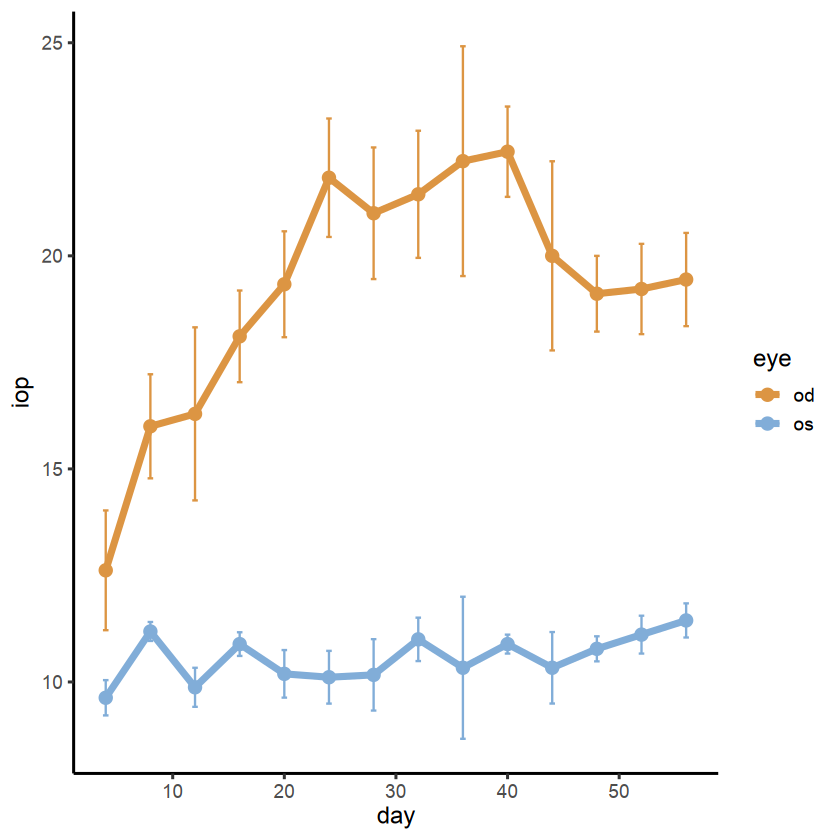

In [5]:
ggplot( df_mean, aes(day, iop, color = eye)) +
    stat_summary(
        fun = mean,
        geom = "line",
        linewidth = 1.5
    ) +
    stat_summary(
        fun = mean,
        geom = "point",
        size = 3
    ) +
    stat_summary(
        fun.data = mean_se,
        geom = "errorbar",
        width = 0.5
    ) +  
    scale_color_manual(
        values = c(
            od = "#DC9543",
            os = "#81ADD8"
        )
    ) +
    theme_classic(base_size = 14)